# 02 — SQL Exploration

Loads the raw KOI data from notebook 01 into a SQLite database, then explores
it with SQL before any pandas analysis — the way you'd interrogate a real
database in a data job.

In [1]:
import pandas as pd
import sqlite3
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
viz = pd.read_csv("../data/raw/koi_cumulative.csv")
print("Loaded for plotting:", viz.shape)

Loaded for plotting: (9564, 153)


In [2]:
df = pd.read_csv("../data/raw/koi_cumulative.csv")

conn = sqlite3.connect("../data/koi.db")

# Convert to strings before loading: some catalog values exceed SQLite's
# 64-bit integer limit and overflow at the pandas→sqlite handoff. Storing
# as TEXT sidesteps it; we CAST back to numbers inside queries that do math.
df_text = df.astype(str)
df_text.to_sql("koi", conn, if_exists="replace", index=False)

print("Loaded", len(df_text), "rows into table 'koi'")

Loaded 9564 rows into table 'koi'


In [3]:
def q(sql):
    """Run a SQL query against the koi database, return results as a DataFrame."""
    return pd.read_sql_query(sql, conn)

In [4]:
q("""
SELECT koi_disposition, COUNT(*) AS n
FROM koi
GROUP BY koi_disposition
""")

,koi_disposition,n
0,CANDIDATE,1978
1,CONFIRMED,2747
2,FALSE POSITIVE,4839


**Interpretation:** The three classes are imbalanced. False positives are the
largest group at 4,839 (~51% of all rows), followed by 2,747 confirmed planets
and 1,978 candidates. Because roughly half the data is one class, a model that
blindly guessed "false positive" every time would already be ~51% accurate —
which is why accuracy alone will be misleading later, and why the modeling
notebook will lean on precision, recall, and F1 instead.

In [5]:
q("""
SELECT koi_disposition,
       ROUND(AVG(CAST(koi_period AS REAL)), 2) AS avg_period,
       ROUND(AVG(CAST(koi_prad AS REAL)), 2) AS avg_radius
FROM koi
GROUP BY koi_disposition
""")

,koi_disposition,avg_period,avg_radius
0,CANDIDATE,167.78,97.95
1,CONFIRMED,27.90,2.86
2,FALSE POSITIVE,65.14,164.84


**Interpretation:** Average planet radius separates the classes sharply.
Confirmed planets average just 2.86 Earth radii, while false positives average
164.84 — roughly 57× larger. That gap makes physical sense: many false
positives are eclipsing binaries (two stars), and a star dwarfs a planet, so an
implausibly huge "planet" radius is a strong signal the object isn't a planet at
all. This suggests `koi_prad` will be a useful predictive feature later.

Orbital period shows no clean pattern across classes, so it looks less
discriminating on its own.

Caveat: these are averages, which outliers can distort — the false-positive
radius mean is likely inflated by a few extreme values. The median would be more
robust, and outlier handling is a job for the cleaning notebook.

In [6]:
q("""
SELECT COUNT(*) AS missing_radius
FROM koi
WHERE koi_prad IS NULL OR koi_prad != koi_prad
""")

,missing_radius
0,363


**Interpretation:** `koi_prad` has **363 missing values** — but they only
surfaced after probing how missingness was encoded. An initial check for the
string `'nan'` returned 0, because the values are stored as true numeric NaN,
not text. NaN's defining quirk — it never equals itself — is what finally
caught them (`koi_prad != koi_prad`). Lesson: a "0 missing" result is worth a
second look, since missing data hides under many encodings. Handling these 363
gaps is a job for the cleaning notebook.

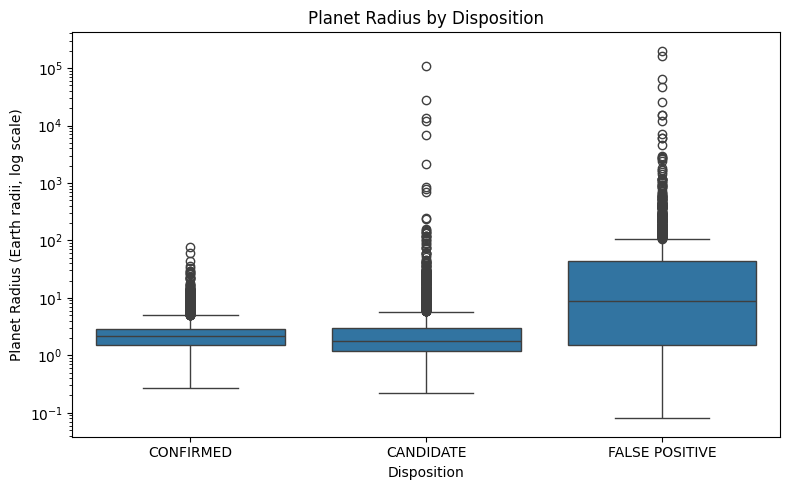

In [7]:
# Planet radius by class. Log scale because radii span a huge range
# (small planets to giant false positives) — without it, the planets get
# squashed into an invisible sliver at the bottom.
plt.figure(figsize=(8, 5))
sns.boxplot(data=viz, x="koi_disposition", y="koi_prad",
            order=["CONFIRMED", "CANDIDATE", "FALSE POSITIVE"])
plt.yscale("log")
plt.title("Planet Radius by Disposition")
plt.xlabel("Disposition")
plt.ylabel("Planet Radius (Earth radii, log scale)")
plt.tight_layout()
plt.show()

**Interpretation:** The boxplot makes the radius separation visual. Confirmed
planets and candidates cluster low (roughly 1–3 Earth radii — planet-sized),
while false positives sit much higher, with a box centered an order of
magnitude up and a long tail of giant objects. That gap is the visual form of
the ~57× difference in mean radius found earlier: many false positives are
eclipsing binaries or other stellar-sized objects, so an implausibly large
"planet" radius is a strong signal it isn't a planet. A log scale is used on
the y-axis because radii span several orders of magnitude — on a linear axis
the planet-sized objects would be crushed into an invisible sliver at the
bottom. This is direct visual evidence that `koi_prad` carries real
discriminating power, which the modeling notebook later confirms (radius ranks
among the top features).

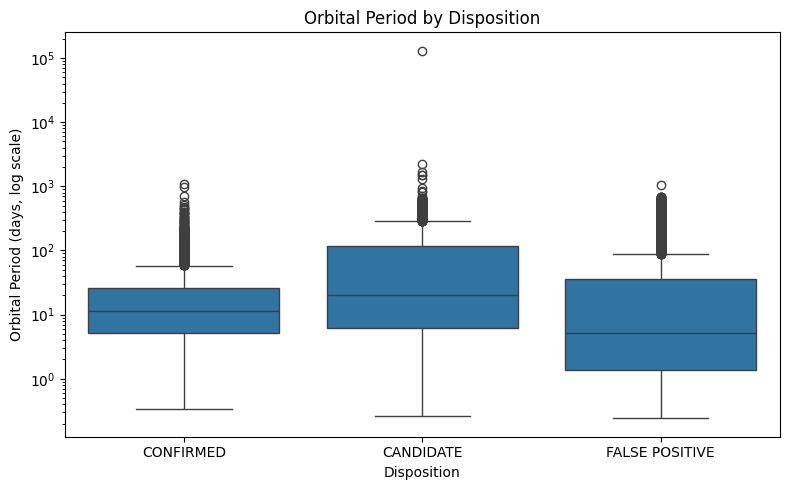

In [8]:
# Orbital period by class — the feature that did NOT separate cleanly in nb 02.
# Showing a non-discriminating feature alongside a strong one is more honest
# than only showing what works.
plt.figure(figsize=(8, 5))
sns.boxplot(data=viz, x="koi_disposition", y="koi_period",
            order=["CONFIRMED", "CANDIDATE", "FALSE POSITIVE"])
plt.yscale("log")
plt.title("Orbital Period by Disposition")
plt.xlabel("Disposition")
plt.ylabel("Orbital Period (days, log scale)")
plt.tight_layout()
plt.show()

**Interpretation:** Unlike radius, orbital period does **not** cleanly separate
the classes — the three boxes overlap heavily, all centered in roughly the same
range (~1–100 days). A planet and a false positive can have similar orbital
periods, so period on its own carries little discriminating power. This is the
honest counterpoint to the radius plot: not every feature is useful, and showing
a weak separator alongside a strong one reflects how real feature exploration
goes. The model doesn't rely on any single feature — it combines many, letting
strong separators like radius do the heavy lifting while weak ones like period
contribute little.

## Summary

Loaded the raw KOI data into a SQLite database and explored it with SQL before
any modeling, then visualized the key distributions.

**SQL findings:**
- **Class balance is uneven** — 4,839 false positives (~51%), 2,747 confirmed,
  1,978 candidates. This imbalance is why later modeling uses precision/recall/F1
  rather than accuracy.
- **Planet radius separates the classes sharply** — confirmed planets average
  ~2.9 Earth radii vs ~165 for false positives (~57×), since many false
  positives are stellar-sized eclipsing binaries.
- **Orbital period does not** separate them cleanly.
- **`koi_prad` has 363 missing values**, which only surfaced after checking how
  missingness was encoded — handled in the cleaning notebook.

**Visualizations:** confirmed the above visually — the class-balance bar chart,
a radius boxplot showing the clear separation (strong feature), and a period
boxplot showing heavy overlap (weak feature).

**Next:** notebook 03 — cleaning and the leakage hunt, where these findings
inform which columns to keep, drop, and impute.